In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
from torch.utils.data import DataLoader, Dataset, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

import os
import kagglehub
 
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [8]:
# Download latest version
path = kagglehub.dataset_download("hamzamohiuddin/isbi-2012-challenge")

print("Path to dataset files:", path)

100%|██████████| 12.6M/12.6M [00:01<00:00, 7.12MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/hamzamohiuddin/isbi-2012-challenge/versions/1


In [9]:
class ISBIDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        """
        Args:
            root_dir: The path variable from kagglehub
            split: "train" or "test"
            transform: Augmentations
        """
        self.split = split
        self.img_dir = os.path.join(root_dir, split, "imgs")
        self.label_dir = os.path.join(root_dir, split, "labels")
        
        self.images = sorted(os.listdir(self.img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load Image
        img_path = os.path.join(self.img_dir, self.images[idx])
        image = np.array(Image.open(img_path).convert("L"), dtype=np.float32) / 255.0
        
        # Load Label (if training)
        mask = None
        if self.split == "train":
            mask_path = os.path.join(self.label_dir, self.images[idx])
            mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32) / 255.0
            mask = (mask > 0.5).astype(np.float32) # Ensure binary

        if self.transform:
            # Note: If using Albumentations, you'd apply it to both image and mask here
            pass

        # Add Channel Dim [C, H, W]
        image = torch.from_numpy(image).unsqueeze(0)
        
        if self.split == "train":
            mask = torch.from_numpy(mask).unsqueeze(0)
            return image, mask
        
        return image

In [10]:
full_path = path + '/unmodified-data/'
full_train_ds = ISBIDataset(root_dir=full_path, split='train')
test_ds = ISBIDataset(root_dir=full_path, split='test')

train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size

train_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

train_loader = DataLoader(
    train_ds, 
    batch_size=4, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

# Check a batch
images, labels = next(iter(train_loader))
print(f"Images: {images.shape}") # [4, 1, 512, 512]
print(f"Labels: {labels.shape}") # [4, 1, 512, 512]

Images: torch.Size([4, 1, 512, 512])
Labels: torch.Size([4, 1, 512, 512])


In [11]:
class DoubleConv(nn.Module):
    """
    Two consecutive (Conv → BatchNorm → ReLU) operations.
    This is the basic repeated unit in both encoder and decoder.

    Weight shapes (for SVD later):
        conv1.weight : (out_ch, in_ch, 3, 3)
        conv2.weight : (out_ch, out_ch, 3, 3)
    """

    def __init__(self, in_channels: int, out_channels: int, mid_channels: int = None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.block = nn.Sequential(OrderedDict([
            ("conv1", nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False)),
            ("bn1",   nn.BatchNorm2d(mid_channels)),
            ("relu1", nn.ReLU(inplace=True)),
            ("conv2", nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False)),
            ("bn2",   nn.BatchNorm2d(out_channels)),
            ("relu2", nn.ReLU(inplace=True)),
        ]))

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Encoder step: MaxPool → DoubleConv (halves spatial dims)."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    """
    Decoder step: Upsample → concat skip → DoubleConv (doubles spatial dims).
    
    Skip connection arrives here as the second argument to forward().
    """

    def __init__(self, in_channels: int, out_channels: int, bilinear: bool = True):
        super().__init__()
        if bilinear:
            # Bilinear upsample then halve channels with 1×1 conv
            self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, mid_channels=in_channels // 2)
        else:
            # Learned transposed convolution (also interesting to SVD)
            self.up   = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)

        # Pad if input is not perfectly divisible (odd spatial dims)
        dy = skip.size(2) - x.size(2)
        dx = skip.size(3) - x.size(3)
        x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])

        # ── Skip connection concatenation ──
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    """
    Configurable U-Net.

    Parameters
    ----------
    in_channels   : input image channels (1 = grayscale, 3 = RGB)
    out_channels  : number of segmentation classes
    base_channels : feature channels at the first encoder level (doubles each level)
    depth         : number of down/up-sampling stages (encoder levels excluding bottleneck)
    bilinear      : True  → bilinear upsampling (fewer params)
                    False → transposed conv (learnable upsampling, more to SVD)

    Architecture (depth=4, base=64)
    --------------------------------
    Input → [64] → [128] → [256] → [512] → [1024] (bottleneck)
                                         ↕  skip[3]
                              [512] ← Up(1024+512)
                         ↕  skip[2]
                   [256] ← Up(512+256)
              ↕  skip[1]
        [128] ← Up(256+128)
    ↕  skip[0]
    [64]  ← Up(128+64)
    → Output conv → logits
    """

    def __init__(
        self,
        in_channels:   int  = 1,
        out_channels:  int  = 2,
        base_channels: int  = 64,
        depth:         int  = 4,
        bilinear:      bool = True,
    ):
        super().__init__()
        self.depth    = depth
        self.bilinear = bilinear

        # ── Encoder ──────────────────────────────────────────────────────────
        # enc[0] : initial conv (no pooling)
        # enc[1..depth-1] : Down blocks
        self.encoder = nn.ModuleList()
        self.encoder.append(DoubleConv(in_channels, base_channels))
        ch = base_channels
        for _ in range(depth - 1):
            self.encoder.append(Down(ch, ch * 2))
            ch *= 2

        # ── Bottleneck ───────────────────────────────────────────────────────
        factor = 2 if bilinear else 1
        self.bottleneck = Down(ch, ch * 2 // factor)
        ch = ch * 2 // factor

        # ── Decoder ──────────────────────────────────────────────────────────
        # Symmetric to encoder; skip from enc[depth-1] down to enc[0]
        self.decoder = nn.ModuleList()
        for i in range(depth - 1, 0, -1):
            skip_ch = base_channels * (2 ** i)
            self.decoder.append(Up(ch + skip_ch, skip_ch // factor, bilinear))
            ch = skip_ch // factor

        self.decoder.append(Up(ch + base_channels, base_channels, bilinear))

        # ── Output ───────────────────────────────────────────────────────────
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Encode — store intermediate feature maps for skip connections
        skips = []
        for enc_block in self.encoder:
            x = enc_block(x)
            skips.append(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decode — consume skips in reverse order
        for dec_block, skip in zip(self.decoder, reversed(skips)):
            x = dec_block(x, skip)

        return self.out_conv(x)

    # ── Weight extraction helpers (for SVD) ──────────────────────────────────
 
    def get_weight_dict(self) -> dict:
        """
        Returns a flat dict of all conv weight tensors, keyed by human-readable names.
        Each value is a 2D numpy array (out_features × in_features) obtained by
        reshaping the 4D conv kernel (out, in, kH, kW) → (out, in*kH*kW).
 
        This 'unrolled' view is the natural matrix for computing singular values.
 
        Keys follow the pattern:
            "encoder_L{i}_conv{j}"   — encoder level i, conv layer j
            "bottleneck_conv{j}"
            "decoder_L{i}_conv{j}"   — decoder level i (from top of decoder)
        """
        weights = {}
 
        def extract_double_conv(prefix, double_conv: DoubleConv):
            for name in ["conv1", "conv2"]:
                w = getattr(double_conv.block, name).weight.detach().cpu()
                # Reshape (out, in, kH, kW) → (out, in*kH*kW)
                weights[f"{prefix}_{name}"] = w.reshape(w.shape[0], -1).numpy()
 
        # Encoder
        for i, block in enumerate(self.encoder):
            conv = block if isinstance(block, DoubleConv) else block.conv
            extract_double_conv(f"encoder_L{i}", conv)
 
        # Bottleneck
        extract_double_conv("bottleneck", self.bottleneck.conv)
 
        # Decoder
        for i, block in enumerate(self.decoder):
            extract_double_conv(f"decoder_L{i}", block.conv)
 
        return weights
 
    def save_weights_for_analysis(self, path: str):
        """
        Save structured weights to a .pt file.
        Loads back with:
            data = torch.load('weights.pt')
            data['weight_dict']   # flat dict of 2D numpy arrays
            data['model_state']   # full state dict to restore model
            data['config']        # hyperparameters
        """
        torch.save({
            "model_state": self.state_dict(),
            "weight_dict": self.get_weight_dict(),
            "config": {
                "depth":         self.depth,
                "bilinear":      self.bilinear,
            }
        }, path)
        print(f"Saved weights → {path}")

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Standard single-epoch training loop."""
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        masks = masks.to(device).squeeze(1).long()

        optimizer.zero_grad()
        logits = model(imgs)

        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

In [21]:
model = UNet(
    in_channels=1,
    out_channels=2,
    base_channels=64,
    depth=3,
    bilinear=True,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print("Total UNet parameters:", num_params)

old_path = "initial_weights.pt"
model.save_weights_for_analysis(old_path)

lr = 1e-3
num_epochs = 100
print_interval = 10

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device).squeeze(1).long()

            outputs = model(imgs)
            val_loss += criterion(outputs, masks).item()
        
    val_loss /= len(val_loader)

    if epoch % print_interval == 0:
        print(f"Epoch {epoch:3d}/{num_epochs}\t"
            f"train_loss={train_loss:.4f}\tval_loss={val_loss:.4f}")
    
new_path = "trained_weights.pt"
model.save_weights_for_analysis(new_path)

Total UNet parameters: 4281154
Saved weights → initial_weights.pt
Epoch  10/100	train_loss=0.1935	val_loss=0.2429
Epoch  20/100	train_loss=0.1677	val_loss=0.2307
Epoch  30/100	train_loss=0.1504	val_loss=0.2616
Epoch  40/100	train_loss=0.1372	val_loss=0.2138
Epoch  50/100	train_loss=0.1186	val_loss=0.2400
Epoch  60/100	train_loss=0.1025	val_loss=0.2442
Epoch  70/100	train_loss=0.0889	val_loss=0.2654
Epoch  80/100	train_loss=0.0735	val_loss=0.2838
Epoch  90/100	train_loss=0.0678	val_loss=0.2932
Epoch 100/100	train_loss=0.0663	val_loss=0.2963
Saved weights → trained_weights.pt


In [14]:
def compute_svd_stats(weight_matrix: np.ndarray) -> dict:
    """
    Compute SVD and derived spectral statistics for a 2D weight matrix.
 
    Returns
    -------
    dict with:
        S             : singular values (descending)
        effective_rank: number of singular values capturing 95% of energy
        stable_rank   : ||W||_F^2 / ||W||_2^2  (soft rank measure)
        condition_num : S[0] / S[-1]
        energy_curve  : cumulative energy as a function of rank
    """
    U, S, Vh = np.linalg.svd(weight_matrix, full_matrices=False)
 
    energy       = np.cumsum(S**2) / np.sum(S**2)
    eff_rank     = int(np.searchsorted(energy, 0.95)) + 1
    stable_rank  = (np.sum(S**2) / S[0]**2) if S[0] > 0 else 0.0
    condition    = S[0] / S[-1] if S[-1] > 0 else float("inf")
 
    return {
        "S":              S,
        "effective_rank": eff_rank,
        "stable_rank":    stable_rank,
        "condition_num":  condition,
        "energy_curve":   energy,
    }
 
 
def analyse_checkpoint(path: str) -> dict:
    """Load a saved checkpoint and compute SVD stats for every layer."""
    data      = torch.load(path, map_location="cpu", weights_only=False)
    wdict     = data["weight_dict"]
    results   = {}
    for name, W in wdict.items():
        results[name] = {"shape": W.shape, **compute_svd_stats(W)}
        print(f"  {name:35s}  shape={W.shape}  "
              f"eff_rank={results[name]['effective_rank']:3d}  "
              f"stable_rank={results[name]['stable_rank']:.2f}  "
              f"cond={results[name]['condition_num']:.1f}")
    return results
 
 
def paired_encoder_decoder_keys(results: dict):
    """
    Return list of (encoder_key, decoder_key) pairs for symmetric levels.
    Encoder level i is paired with decoder level (depth-1-i).
    """
    enc_keys = sorted([k for k in results if k.startswith("encoder_")])
    dec_keys = sorted([k for k in results if k.startswith("decoder_")],
                      reverse=True)   # decoder_L0 pairs with deepest encoder
    return list(zip(enc_keys, dec_keys))
 
 
# ─────────────────────────────────────────────
#  Plotting
# ─────────────────────────────────────────────
 
def plot_singular_value_spectra(results: dict, save_path: str = None):
    """
    Plot singular value decay for every layer, grouped by encoder/bottleneck/decoder.
    Good for visually comparing spectral structure across the network.
    """
    groups = {
        "encoder":    {k: v for k, v in results.items() if k.startswith("encoder")},
        "bottleneck": {k: v for k, v in results.items() if k.startswith("bottleneck")},
        "decoder":    {k: v for k, v in results.items() if k.startswith("decoder")},
    }
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Singular Value Spectra by Network Section", fontsize=14)
 
    for ax, (group_name, group) in zip(axes, groups.items()):
        for name, stats in group.items():
            S_norm = stats["S"] / stats["S"][0]   # normalize by largest SV
            ax.plot(S_norm, label=name.split("_", 1)[1], alpha=0.8)
        ax.set_title(group_name.capitalize())
        ax.set_xlabel("Singular value index")
        ax.set_ylabel("Normalized singular value")
        ax.legend(fontsize=7)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved spectrum plot → {save_path}")
    plt.show()
 
 
def plot_encoder_decoder_comparison(results: dict, save_path: str = None):
    """
    Key plot for your research: compare singular values at symmetric
    encoder and decoder levels side by side.
 
    If Dec_i ≈ Enc_i* (adjoint), the spectra should be nearly identical.
    Divergence tells you where the symmetry breaks.
    """
    pairs = paired_encoder_decoder_keys(results)
    n     = len(pairs)
    if n == 0:
        print("No symmetric pairs found.")
        return
 
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
 
    fig.suptitle("Encoder vs Decoder: Singular Value Comparison\n"
                 "(Similarity suggests adjoint-like symmetry)", fontsize=13)
 
    for row, (enc_key, dec_key) in enumerate(pairs):
        enc_S = results[enc_key]["S"]
        dec_S = results[dec_key]["S"]
 
        # Left: overlay spectra
        ax = axes[row][0]
        ax.plot(enc_S / enc_S[0], label=f"Encoder ({enc_key})", color="steelblue")
        ax.plot(dec_S / dec_S[0], label=f"Decoder ({dec_key})", color="tomato",
                linestyle="--")
        ax.set_title(f"Level pair {row} — normalized spectra")
        ax.set_xlabel("Index")
        ax.set_ylabel("σᵢ / σ₁")
        ax.set_yscale("log")
        ax.legend()
        ax.grid(True, alpha=0.3)
 
        # Right: ratio of spectra (should be ≈ 1 if adjoint)
        ax2    = axes[row][1]
        min_k  = min(len(enc_S), len(dec_S))
        ratio  = enc_S[:min_k] / (dec_S[:min_k] + 1e-10)
        ax2.plot(ratio, color="purple")
        ax2.axhline(1.0, color="gray", linestyle=":", linewidth=1)
        ax2.set_title(f"Level pair {row} — σ(Enc) / σ(Dec) ratio")
        ax2.set_xlabel("Index")
        ax2.set_ylabel("Ratio")
        ax2.grid(True, alpha=0.3)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved comparison plot → {save_path}")
    plt.show()
 
 
def plot_effective_rank_profile(results: dict, save_path: str = None):
    """
    Plot effective rank and stable rank across the network depth.
    Reveals how much information capacity each layer actually uses.
    Expect a bottleneck shape (low rank at the bottleneck level).
    """
    names     = list(results.keys())
    eff_ranks = [results[n]["effective_rank"] for n in names]
    stb_ranks = [results[n]["stable_rank"]    for n in names]
 
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle("Rank Profile Across Network Depth", fontsize=13)
 
    x = range(len(names))
    ax1.bar(x, eff_ranks, color="steelblue", alpha=0.8)
    ax1.set_ylabel("Effective rank (95% energy)")
    ax1.set_title("Effective rank — expect U-shape (low at bottleneck)")
    ax1.grid(True, axis="y", alpha=0.3)
 
    ax2.bar(x, stb_ranks, color="darkorange", alpha=0.8)
    ax2.set_ylabel("Stable rank  ||W||²_F / ||W||²_2")
    ax2.set_title("Stable rank — measures soft dimensionality")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax2.grid(True, axis="y", alpha=0.3)
 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved rank profile → {save_path}")
    plt.show()

  encoder_L0_conv1                     shape=(64, 9)  eff_rank=  9  stable_rank=6.00  cond=1.7
  encoder_L0_conv2                     shape=(64, 576)  eff_rank= 58  stable_rank=36.63  cond=1.9
  encoder_L1_conv1                     shape=(128, 576)  eff_rank=112  stable_rank=59.87  cond=2.7
  encoder_L1_conv2                     shape=(128, 1152)  eff_rank=116  stable_rank=74.16  cond=1.9
  encoder_L2_conv1                     shape=(256, 1152)  eff_rank=223  stable_rank=117.79  cond=2.7
  encoder_L2_conv2                     shape=(256, 2304)  eff_rank=232  stable_rank=145.80  cond=2.0
  bottleneck_conv1                     shape=(256, 2304)  eff_rank=232  stable_rank=144.42  cond=2.0
  bottleneck_conv2                     shape=(256, 2304)  eff_rank=232  stable_rank=144.19  cond=2.0
  decoder_L0_conv1                     shape=(256, 4608)  eff_rank=236  stable_rank=170.78  cond=1.6
  decoder_L0_conv2                     shape=(128, 2304)  eff_rank=119  stable_rank=84.33  cond=1.6
  d

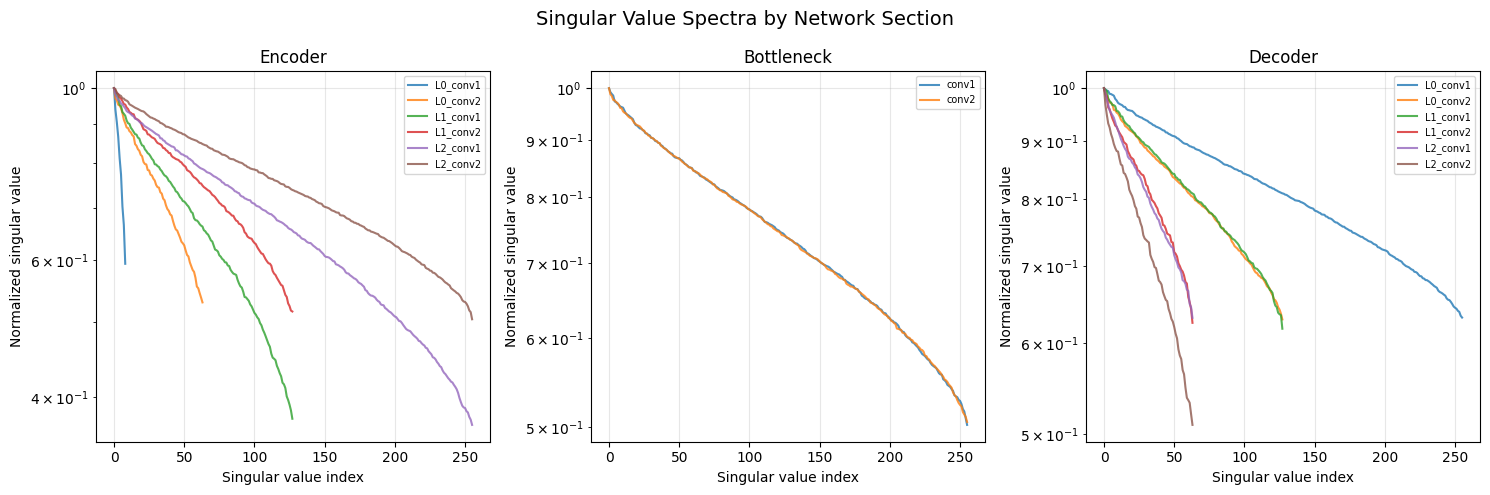

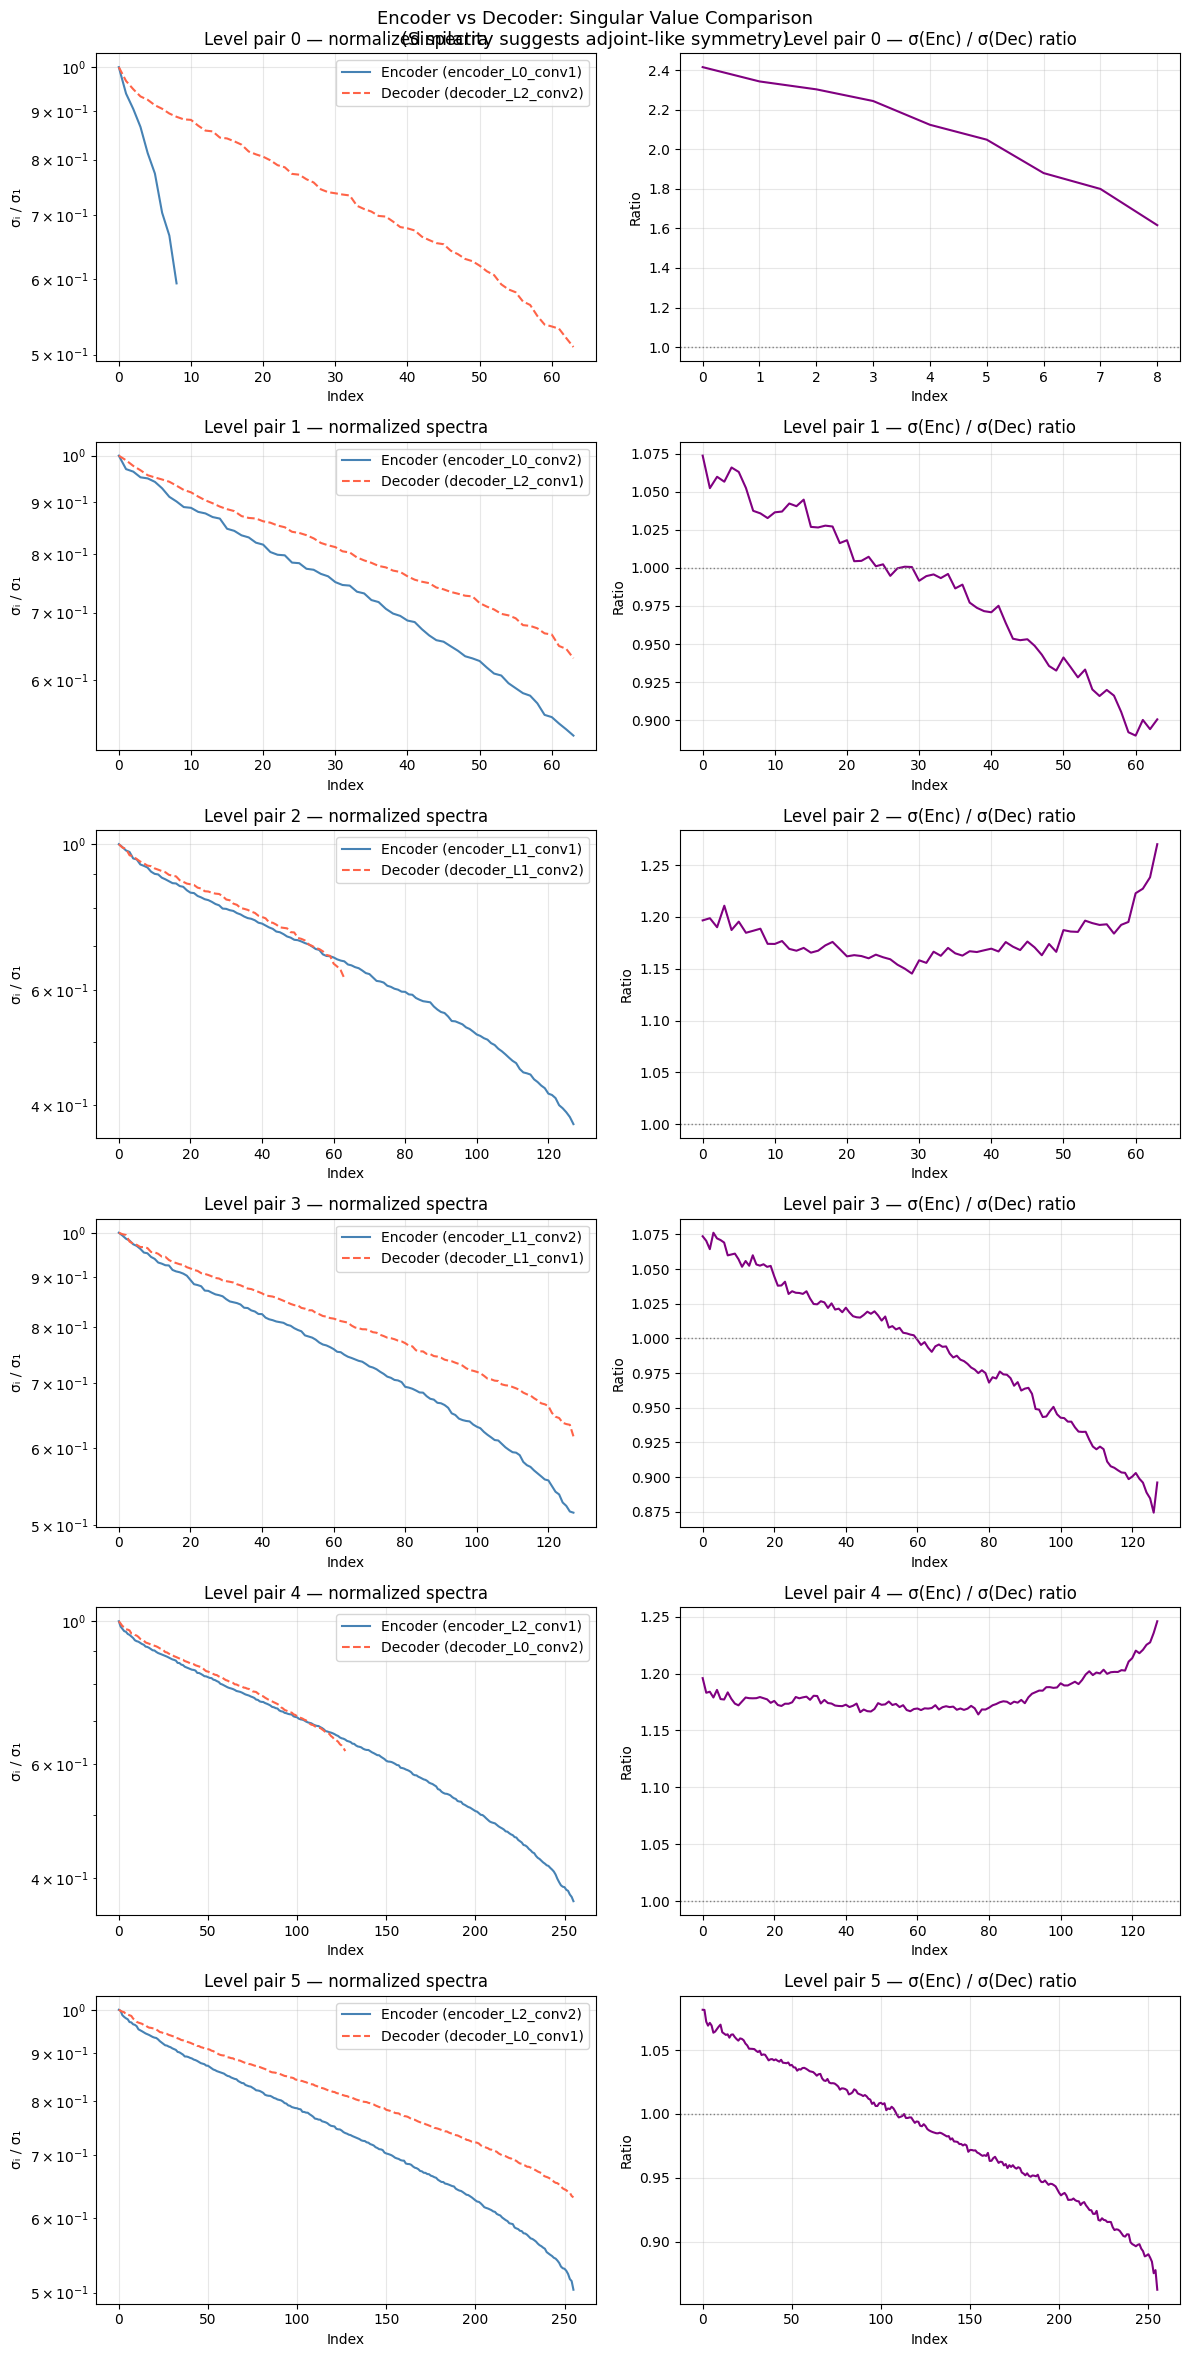

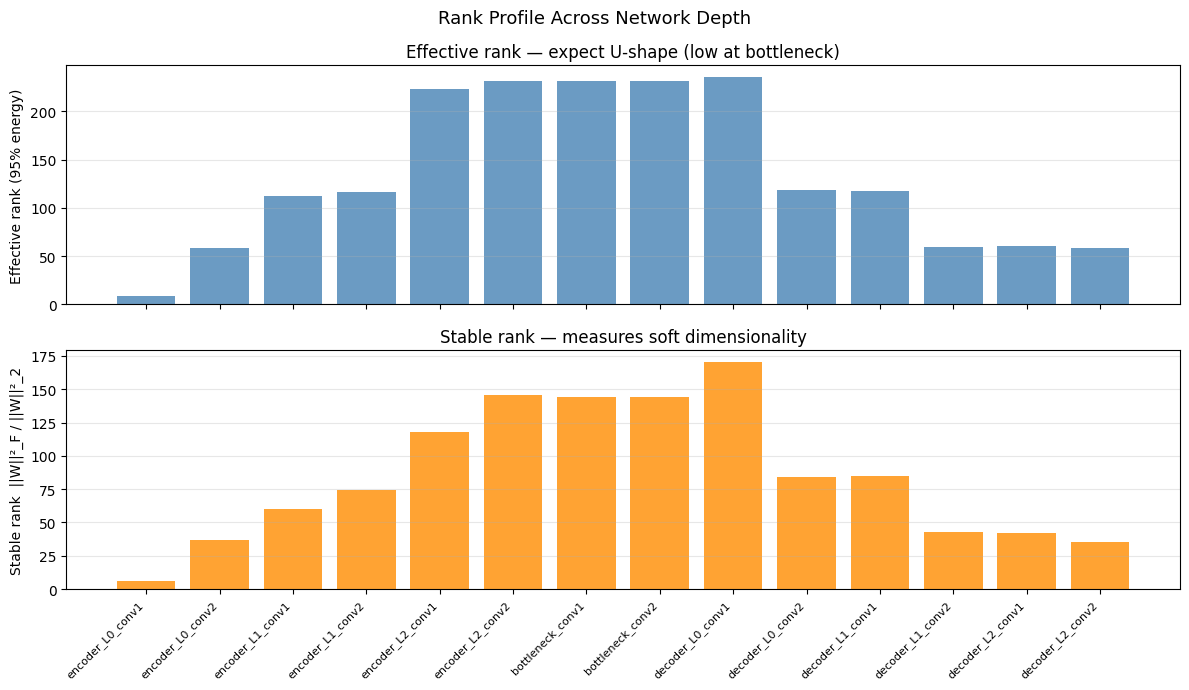

In [22]:
results = analyse_checkpoint(old_path)
plot_singular_value_spectra(results)
plot_encoder_decoder_comparison(results)
plot_effective_rank_profile(results)

  encoder_L0_conv1                     shape=(64, 9)  eff_rank=  9  stable_rank=6.02  cond=1.7
  encoder_L0_conv2                     shape=(64, 576)  eff_rank= 58  stable_rank=24.87  cond=2.3
  encoder_L1_conv1                     shape=(128, 576)  eff_rank=111  stable_rank=37.39  cond=3.5
  encoder_L1_conv2                     shape=(128, 1152)  eff_rank=115  stable_rank=31.26  cond=3.2
  encoder_L2_conv1                     shape=(256, 1152)  eff_rank=219  stable_rank=45.20  cond=4.8
  encoder_L2_conv2                     shape=(256, 2304)  eff_rank=226  stable_rank=35.12  cond=4.6
  bottleneck_conv1                     shape=(256, 2304)  eff_rank=224  stable_rank=23.32  cond=5.8
  bottleneck_conv2                     shape=(256, 2304)  eff_rank=224  stable_rank=25.68  cond=5.5
  decoder_L0_conv1                     shape=(256, 4608)  eff_rank=227  stable_rank=15.74  cond=6.5
  decoder_L0_conv2                     shape=(128, 2304)  eff_rank=116  stable_rank=19.99  cond=3.7
  decode

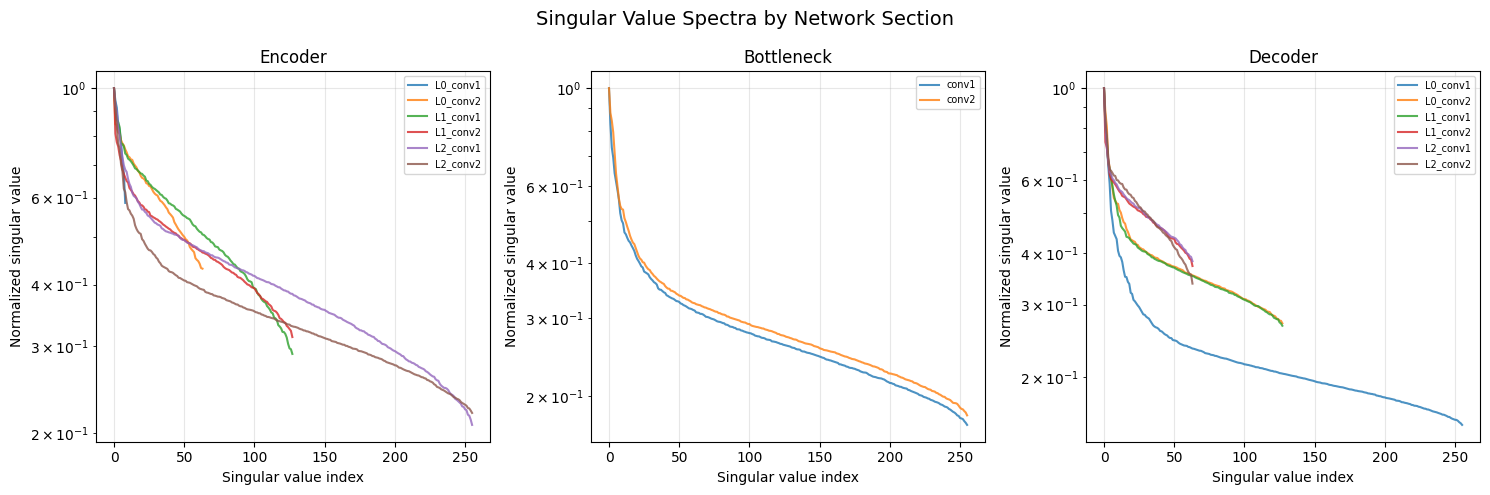

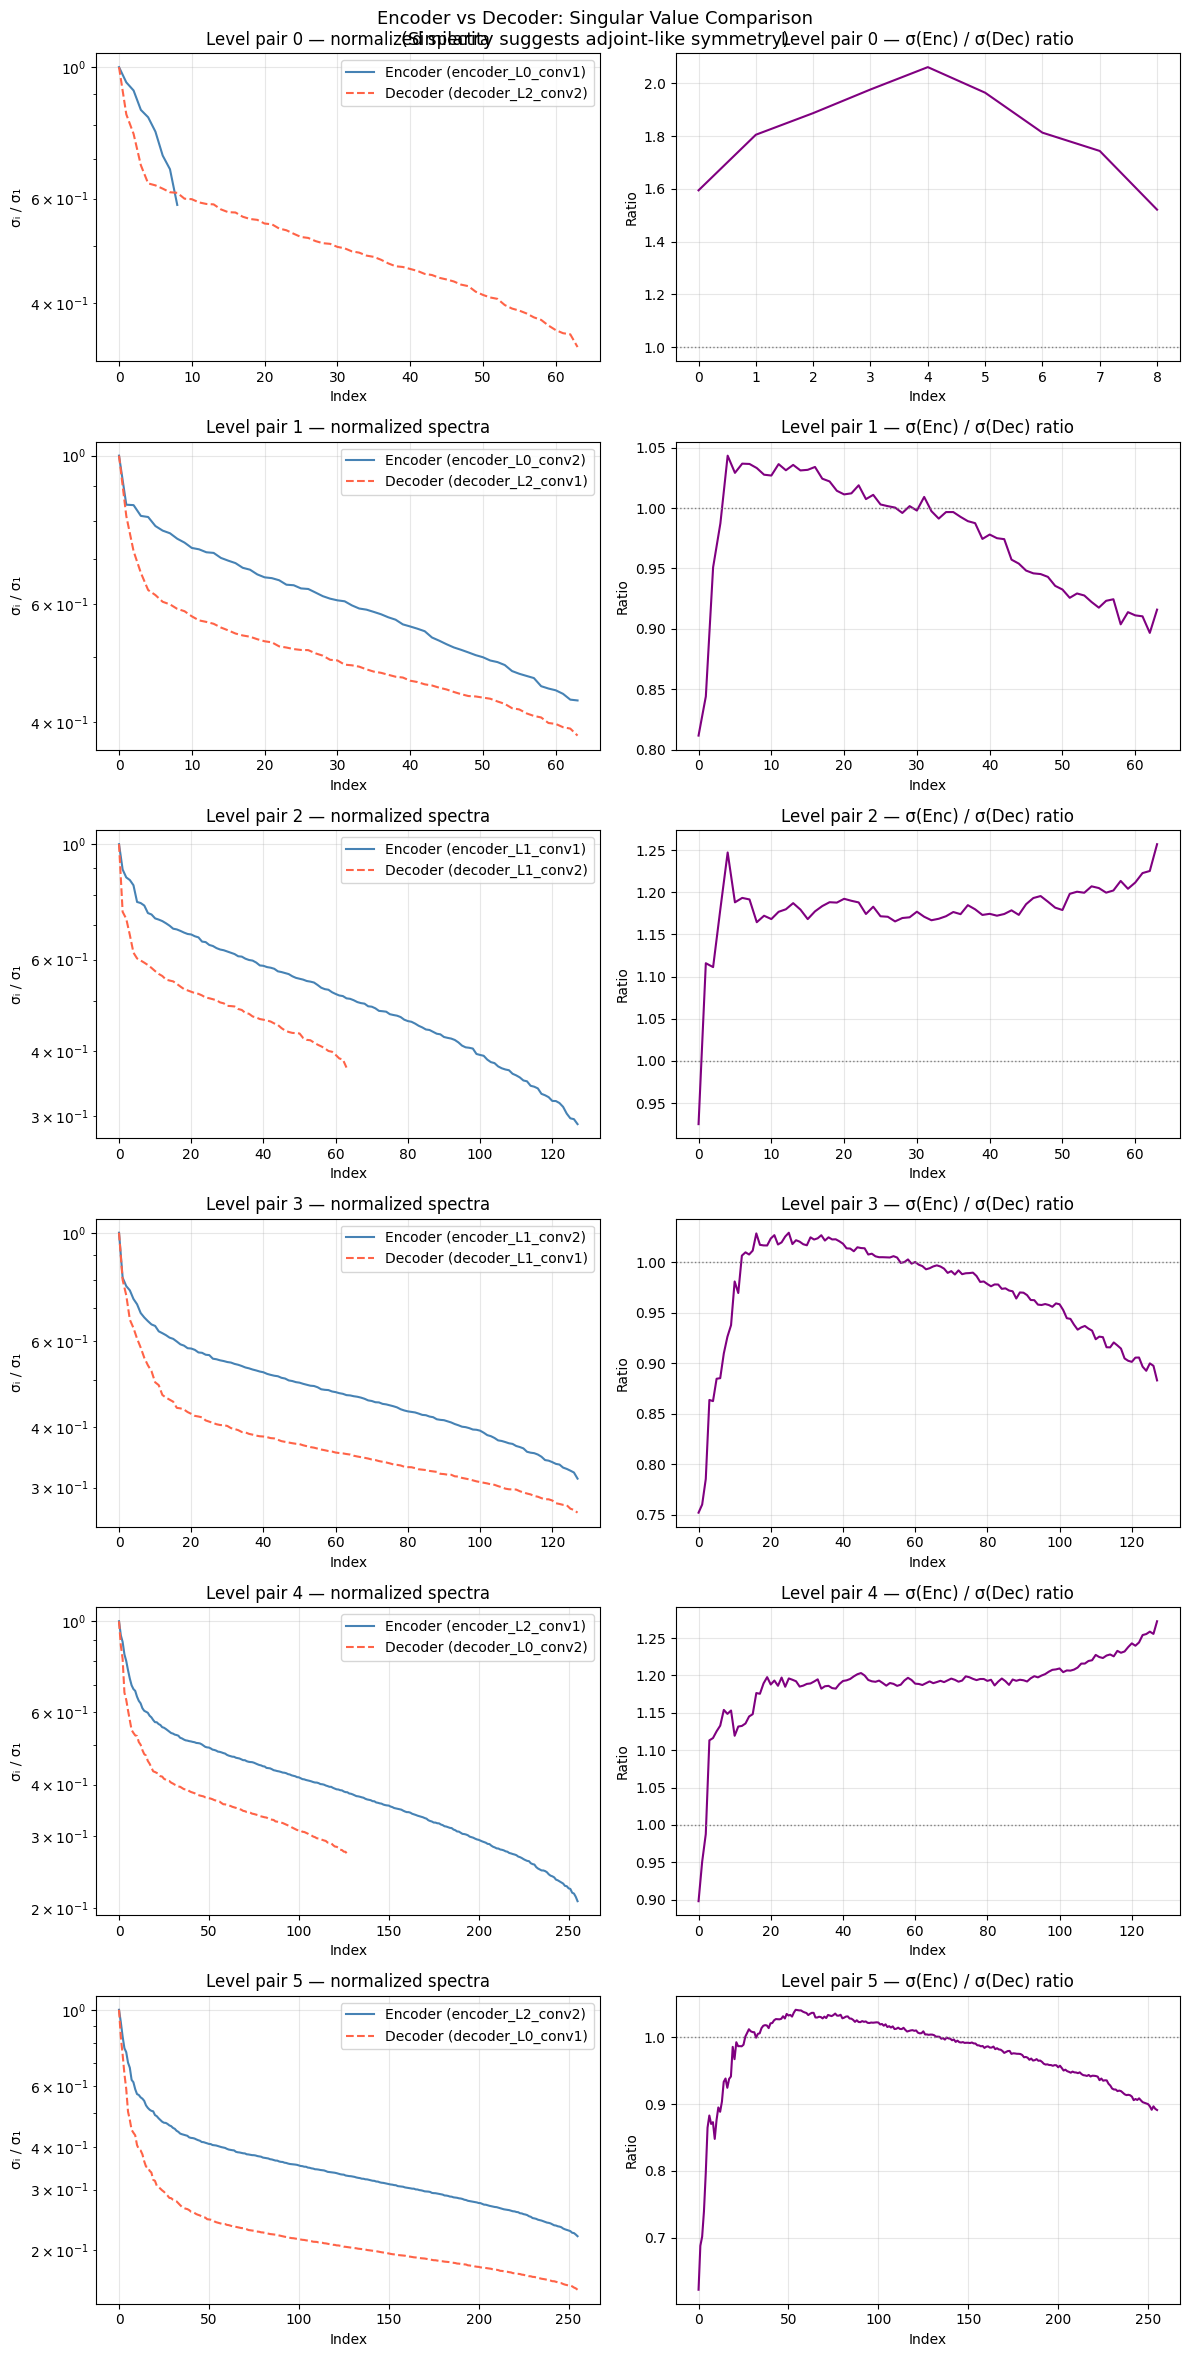

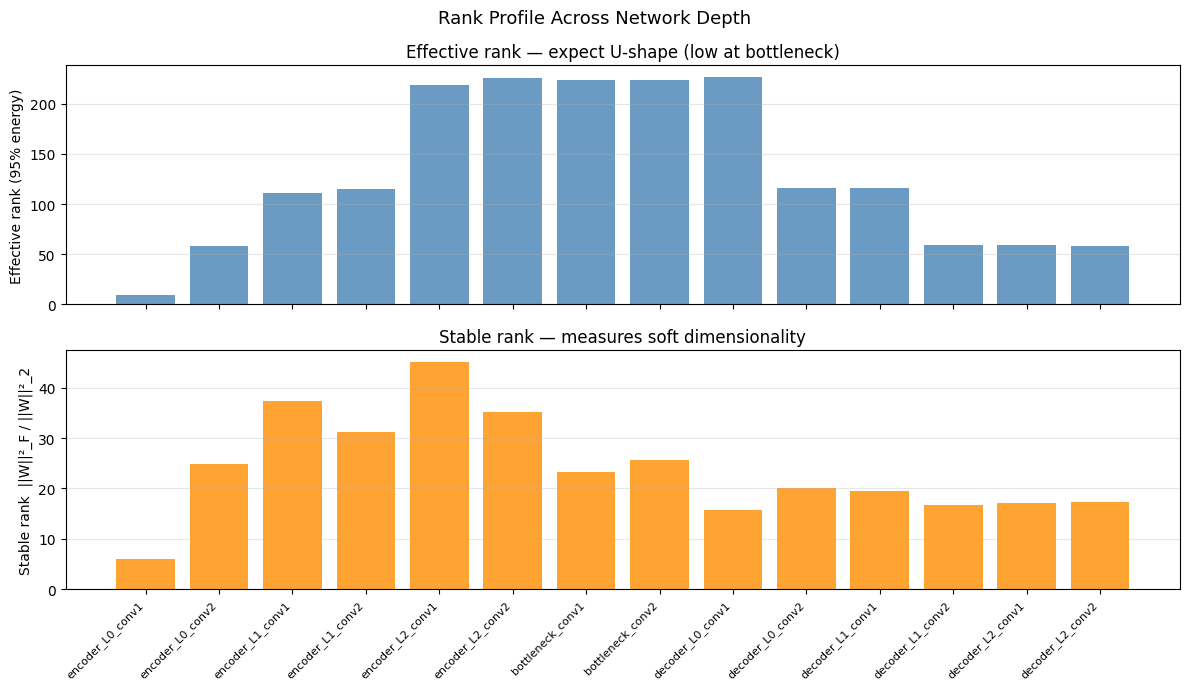

In [23]:
results = analyse_checkpoint(new_path)
plot_singular_value_spectra(results)
plot_encoder_decoder_comparison(results)
plot_effective_rank_profile(results)